In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Data prep
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Classification models

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Ensemble (Voting Classifier)
from sklearn.ensemble import VotingClassifier

# Regression models
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Metrics
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import roc_curve, auc
import plotly.express as px


In [2]:
df = pd.read_csv('/content/loan_approval_data (1).csv')  # Use the cleaned dataset


In [3]:
# Check how many missing values each column has
print('Missing values before cleaning:')
print(df.isnull().sum())

# Fix numeric columns: fill blanks with the middle value (median)
df['age'].fillna(df['age'].median(), inplace=True)
df['loan_interest_rate'].fillna(df['loan_interest_rate'].median(), inplace=True)

# Fix a text column: fill blanks with the most common value (mode)
df['payment_default_on_file'].fillna(df['payment_default_on_file'].mode()[0], inplace=True)

print('\nMissing values after cleaning:')
print(df.isnull().sum())

Missing values before cleaning:
id                          0
age                         6
income                      0
home_ownership              0
emplyment_length            0
loan_intent                 0
loan_amount                 0
loan_interest_rate         11
loan_income_ratio           0
payment_default_on_file     5
credit_history_length       0
loan_approval_status        0
max_allowed_loan            0
dtype: int64

Missing values after cleaning:
id                         0
age                        0
income                     0
home_ownership             0
emplyment_length           0
loan_intent                0
loan_amount                0
loan_interest_rate         0
loan_income_ratio          0
payment_default_on_file    0
credit_history_length      0
loan_approval_status       0
max_allowed_loan           0
dtype: int64


/tmp/ipykernel_1311/2571731219.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
/tmp/ipykernel_1311/2571731219.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [4]:
# Remove columns we don't need for classification
# 'id' is just an ID number, 'max_allowed_loan' is the regression target
df_clf = df.drop(columns=['id', 'max_allowed_loan'])

# Convert text columns (like 'home_ownership', 'loan_intent') into numbers
le = LabelEncoder()
for col in df_clf.select_dtypes(include='object').columns:
    df_clf[col] = le.fit_transform(df_clf[col].astype(str))

# Fill any remaining blanks with the column median
df_clf.fillna(df_clf.median(), inplace=True)

print('Classification dataset ready.')
print('Columns:', df_clf.columns.tolist())

Classification dataset ready.
Columns: ['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length', 'loan_approval_status']


In [5]:
# X = all features (inputs), y = what we want to predict (output)
X_clf = df_clf.drop(columns=['loan_approval_status'])
y_clf = df_clf['loan_approval_status']

# 80% for training, 20% for testing
# stratify=y makes sure both splits have similar % of approved/rejected
X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples : {X_test.shape[0]}')

Training samples: 46916
Testing samples : 11729


In [6]:
scaler = StandardScaler()

# Fit on training data, then apply to both train and test
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('Scaling done.')

Scaling done.


In [7]:
# Define the two base models
lr  = LogisticRegression(random_state=42, max_iter=1000)
nb  = GaussianNB()

# Combine them into one voting ensemble
# voting='soft' uses predicted probabilities (more accurate than hard voting)
ensemble = VotingClassifier(
    estimators=[('lr', lr), ('nb', nb)],
    voting='soft'
)

# Train the ensemble
ensemble.fit(X_train_sc, y_train)

print('Ensemble model trained successfully!')

Ensemble model trained successfully!


In [8]:
# Make predictions on the test set
ens_pred = ensemble.predict(X_test_sc)

# Accuracy = % of correct predictions
acc = accuracy_score(y_test, ens_pred)
print(f'Ensemble Accuracy: {acc:.4f} ({acc*100:.2f}%)')

Ensemble Accuracy: 0.8795 (87.95%)


In [9]:
print(classification_report(y_test, ens_pred, target_names=['Rejected', 'Approved']))

              precision    recall  f1-score   support

    Rejected       0.93      0.93      0.93     10059
    Approved       0.58      0.55      0.57      1670

    accuracy                           0.88     11729
   macro avg       0.75      0.74      0.75     11729
weighted avg       0.88      0.88      0.88     11729



In [10]:
# Train each individual model separately to compare
lr.fit(X_train_sc, y_train)
nb.fit(X_train_sc, y_train)

results = {
    'Logistic Regression': accuracy_score(y_test, lr.predict(X_test_sc)),
    'Naïve Bayes'        : accuracy_score(y_test, nb.predict(X_test_sc)),
    'Ensemble (LR + NB)' : accuracy_score(y_test, ens_pred)
}

print('Model Comparison:')
for name, acc in results.items():
    print(f'  {name:<25} Accuracy = {acc:.4f}')

Model Comparison:
  Logistic Regression       Accuracy = 0.8902
  Naïve Bayes               Accuracy = 0.8493
  Ensemble (LR + NB)        Accuracy = 0.8795


In [11]:
# Predictions for individual base learners
lr_pred = lr.predict(X_test_sc)
lr_prob = lr.predict_proba(X_test_sc)[:, 1]

nb_pred = nb.predict(X_test_sc)
nb_prob = nb.predict_proba(X_test_sc)[:, 1]

# Predictions for ensemble
ens_pred = ensemble.predict(X_test_sc)
ens_prob = ensemble.predict_proba(X_test_sc)[:, 1]

In [12]:
cm_lr = confusion_matrix(y_test, lr_pred)
cm_nb = confusion_matrix(y_test, nb_pred)
cm_ens = confusion_matrix(y_test, ens_pred)

print("Confusion Matrix - LR\n", cm_lr)
print("----"*20)
print("Confusion Matrix - NB\n", cm_nb)
print("----"*20)
print("Confusion Matrix - Ensemble (LR+NB)\n", cm_ens)

Confusion Matrix - LR
 [[9806  253]
 [1035  635]]
--------------------------------------------------------------------------------
Confusion Matrix - NB
 [[8957 1102]
 [ 665 1005]]
--------------------------------------------------------------------------------
Confusion Matrix - Ensemble (LR+NB)
 [[9398  661]
 [ 752  918]]


In [13]:
print("Classification Report - LR\n", classification_report(y_test, lr_pred, target_names=['Rejected','Approved']))
print("----"*20)
print("Classification Report - NB\n", classification_report(y_test, nb_pred, target_names=['Rejected','Approved']))
print("----"*20)
print("Classification Report - Ensemble (LR+NB)\n", classification_report(y_test, ens_pred, target_names=['Rejected','Approved']))

Classification Report - LR
               precision    recall  f1-score   support

    Rejected       0.90      0.97      0.94     10059
    Approved       0.72      0.38      0.50      1670

    accuracy                           0.89     11729
   macro avg       0.81      0.68      0.72     11729
weighted avg       0.88      0.89      0.88     11729

--------------------------------------------------------------------------------
Classification Report - NB
               precision    recall  f1-score   support

    Rejected       0.93      0.89      0.91     10059
    Approved       0.48      0.60      0.53      1670

    accuracy                           0.85     11729
   macro avg       0.70      0.75      0.72     11729
weighted avg       0.87      0.85      0.86     11729

--------------------------------------------------------------------------------
Classification Report - Ensemble (LR+NB)
               precision    recall  f1-score   support

    Rejected       0.93      0.

In [14]:
# Logistic Regression ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
roc_auc_lr = auc(fpr_lr, tpr_lr)
df_lr = pd.DataFrame({'FPR': fpr_lr, 'TPR': tpr_lr})
fig_lr = px.line(df_lr, x='FPR', y='TPR', title=f'ROC Curve - Logistic Regression (AUC = {roc_auc_lr:.4f})')
fig_lr.add_scatter(x=[0,1], y=[0,1], mode='lines', line=dict(dash='dash'), name='Random')
fig_lr.show()





In [15]:
# Naive Bayes ROC
fpr_nb, tpr_nb, _ = roc_curve(y_test, nb_prob)
roc_auc_nb = auc(fpr_nb, tpr_nb)
df_nb = pd.DataFrame({'FPR': fpr_nb, 'TPR': tpr_nb})
fig_nb = px.line(df_nb, x='FPR', y='TPR', title=f'ROC Curve - Naive Bayes (AUC = {roc_auc_nb:.4f})')
fig_nb.add_scatter(x=[0,1], y=[0,1], mode='lines', line=dict(dash='dash'), name='Random')
fig_nb.show()

In [16]:
# Ensemble ROC
fpr_ens, tpr_ens, _ = roc_curve(y_test, ens_prob)
roc_auc_ens = auc(fpr_ens, tpr_ens)
df_ens = pd.DataFrame({'FPR': fpr_ens, 'TPR': tpr_ens})
fig_ens = px.line(df_ens, x='FPR', y='TPR', title=f'ROC Curve - Ensemble (LR + NB) (AUC = {roc_auc_ens:.4f})')
fig_ens.add_scatter(x=[0,1], y=[0,1], mode='lines', line=dict(dash='dash'), name='Random')
fig_ens.show()

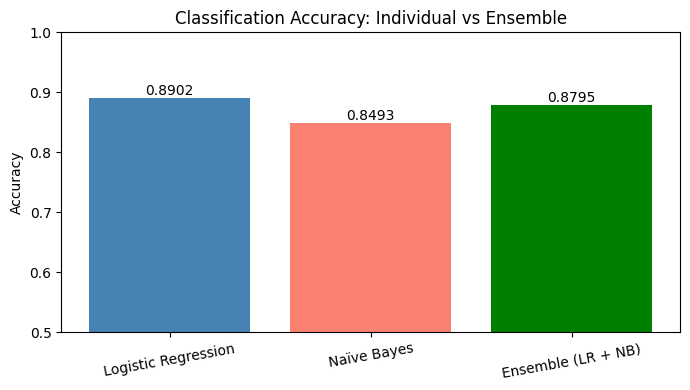

In [17]:
# Bar chart to visualise the comparison
plt.figure(figsize=(7, 4))
plt.bar(results.keys(), results.values(), color=['steelblue', 'salmon', 'green'])
plt.ylim(0.5, 1.0)
plt.ylabel('Accuracy')
plt.title('Classification Accuracy: Individual vs Ensemble')
plt.xticks(rotation=10)
for i, (k, v) in enumerate(results.items()):
    plt.text(i, v + 0.005, f'{v:.4f}', ha='center')
plt.tight_layout()
plt.show()

In [18]:
# Regression dataset: use ALL clients (not just approved)
# REASON: approved clients all have max_allowed_loan = 0 (constant),
# which makes any model trivially perfect (MSE=0, R²=1).
# The real variation in max_allowed_loan exists across all clients.
df_reg = df.copy()

# Remove 3 rows with corrupted negative max_allowed_loan values
df_reg = df_reg[df_reg['max_allowed_loan'] >= 0].copy()
print(f'Regression dataset rows: {df_reg.shape[0]}')

# Drop columns not needed for regression
df_reg = df_reg.drop(columns=['id', 'loan_approval_status'])

# Encode text columns into numbers
le2 = LabelEncoder()
for col in df_reg.select_dtypes(include='object').columns:
    df_reg[col] = le2.fit_transform(df_reg[col].astype(str))

df_reg.fillna(df_reg.median(), inplace=True)

print('Regression dataset ready.')
print('Features:', df_reg.drop(columns=['max_allowed_loan']).columns.tolist())
print(df_reg.head())


Regression dataset rows: 58642
Regression dataset ready.
Features: ['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length']
    age  income  home_ownership  emplyment_length  loan_intent  loan_amount  \
3  40.0  182004               3                 3            1        35000   
4  40.0   90000               0                 3            2        35000   
5  40.0  131004               0                 9            5        30000   
6  40.0  150000               0                 9            0        25000   
7  40.0  132000               0                 3            2        25000   

   loan_interest_rate  loan_income_ratio  payment_default_on_file  \
3                8.00               0.19                        0   
4               12.42               0.39                        0   
5                7.90               0.23                        0   
6

In [19]:
# X = features, y = maximum loan amount (what we want to predict)
X_reg = df_reg.drop(columns=['max_allowed_loan'])
y_reg = df_reg['max_allowed_loan']

# 80% train, 20% test
X_tr, X_te, y_tr, y_te = train_test_split(
    X_reg, y_reg,
    test_size=0.2,
    random_state=42
)

print(f'Training rows: {X_tr.shape[0]}')
print(f'Testing rows : {X_te.shape[0]}')

Training rows: 46913
Testing rows : 11729


In [20]:
dt1 = DecisionTreeRegressor(random_state=42)  # no max_depth = fully grown
dt1.fit(X_tr, y_tr)

DecisionTreeRegressor(random_state=42)

In [21]:
# max_depth limits how complex the tree gets (avoids overfitting)
dt2 = DecisionTreeRegressor(max_depth=5, random_state=42)
dt2.fit(X_tr, y_tr)

# Make predictions for both trees
dt1_pred = dt1.predict(X_te)
dt2_pred = dt2.predict(X_te)

print('DT-1 (Fully Grown) Regression Test Results:')
print(f'  MSE  : {mean_squared_error(y_te, dt1_pred):,.2f}')
print(f'  MAE  : £{mean_absolute_error(y_te, dt1_pred):,.2f}')
print(f'  R²   : {r2_score(y_te, dt1_pred):.4f}')

print('\nDT-2 (Pruned, max_depth=5) Regression Test Results:')
print(f'  MSE  : {mean_squared_error(y_te, dt2_pred):,.2f}')
print(f'  MAE  : £{mean_absolute_error(y_te, dt2_pred):,.2f}')
print(f'  R²   : {r2_score(y_te, dt2_pred):.4f}')


DT-1 (Fully Grown) Regression Test Results:
  MSE  : 584,009,169.10
  MAE  : £7,748.41
  R²   : 0.8081

DT-2 (Pruned, max_depth=5) Regression Test Results:
  MSE  : 656,128,727.31
  MAE  : £15,581.38
  R²   : 0.7844


In [22]:
# dt1_pred and dt2_pred are already defined in Cell 21 above
# (this cell is kept as a placeholder — no changes needed here)


In [23]:
print("\nEnsemble Classifier Metrics:")
print("Accuracy:", accuracy_score(y_test, ens_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, ens_pred))
print("\nClassification Report:\n", classification_report(y_test, ens_pred))


Ensemble Classifier Metrics:
Accuracy: 0.8795293716429363

Confusion Matrix:
 [[9398  661]
 [ 752  918]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93     10059
           1       0.58      0.55      0.57      1670

    accuracy                           0.88     11729
   macro avg       0.75      0.74      0.75     11729
weighted avg       0.88      0.88      0.88     11729



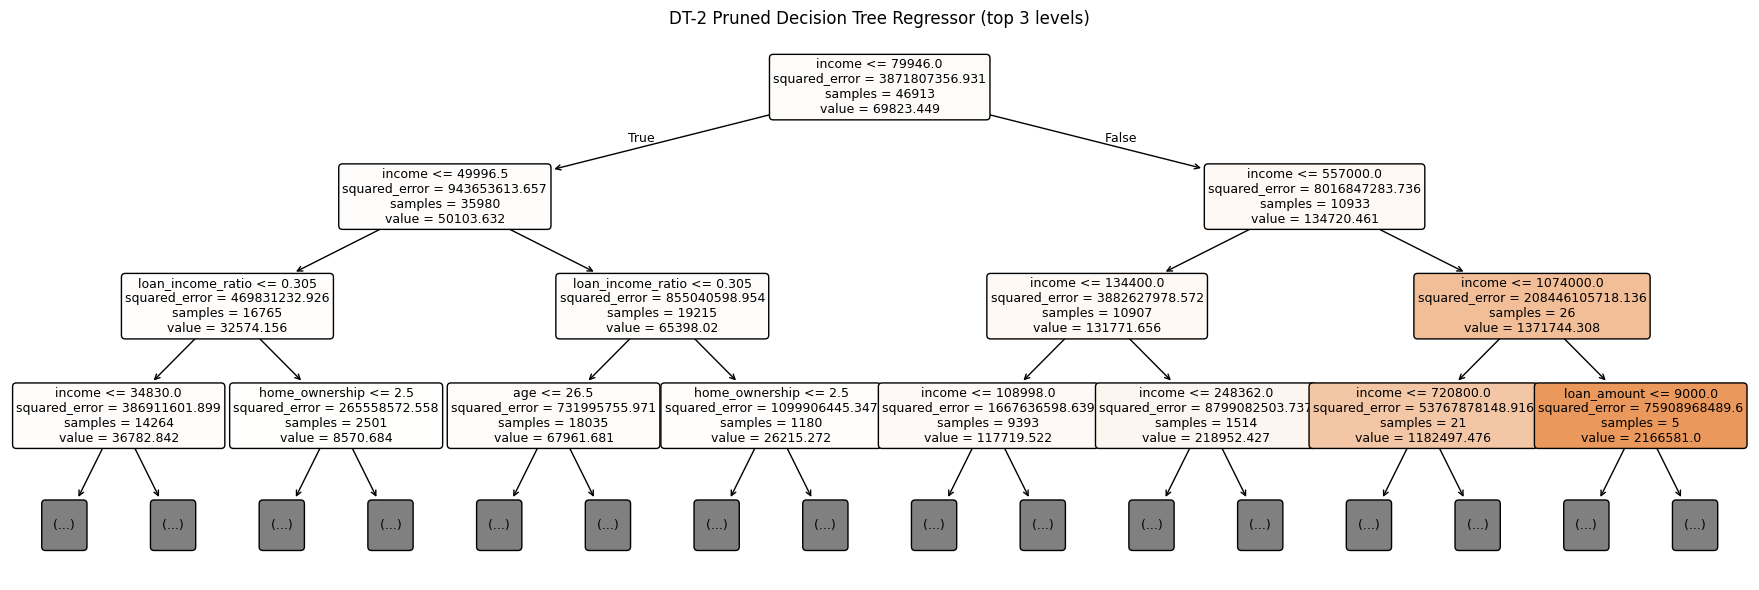

In [24]:
# Visualise the Pruned Decision Tree DT-2 (top 3 levels for readability)
plt.figure(figsize=(18, 6))
plot_tree(
    dt2,
    max_depth=3,
    feature_names=X_reg.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title('DT-2 Pruned Decision Tree Regressor (top 3 levels)')
plt.tight_layout()
plt.show()


In [25]:
# n_estimators = how many trees to build
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_tr, y_tr)

rf_pred = rf.predict(X_te)

print('Random Forest Regression Results:')
print(f'  MAE  : £{mean_absolute_error(y_te, rf_pred):,.2f}')
print(f'  RMSE : £{np.sqrt(mean_squared_error(y_te, rf_pred)):,.2f}')
print(f'  R²   : {r2_score(y_te, rf_pred):.4f}')

Random Forest Regression Results:
  MAE  : £8,342.18
  RMSE : £18,233.29
  R²   : 0.8907


In [26]:
gb = GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=42)
gb.fit(X_tr, y_tr)

gb_pred = gb.predict(X_te)

print("Gradient Boosting:")
print("MAE:", mean_absolute_error(y_te, gb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_te, gb_pred)))
print("R²:", r2_score(y_te, gb_pred))

Gradient Boosting:
MAE: 8173.547587426089
RMSE: 16961.1743702018
R²: 0.9054579268609593


In [27]:
# Summary comparison table
reg_results = pd.DataFrame({
    'Model': ['DT-1 Fully Grown', 'DT-2 Pruned (depth=5)', 'Random Forest', 'Gradient Boosting'],
    'MAE (£)': [
        mean_absolute_error(y_te, dt1_pred),
        mean_absolute_error(y_te, dt2_pred),
        mean_absolute_error(y_te, rf_pred),
        mean_absolute_error(y_te, gb_pred)
    ],
    'MSE': [
        mean_squared_error(y_te, dt1_pred),
        mean_squared_error(y_te, dt2_pred),
        mean_squared_error(y_te, rf_pred),
        mean_squared_error(y_te, gb_pred)
    ],
    'R²': [
        r2_score(y_te, dt1_pred),
        r2_score(y_te, dt2_pred),
        r2_score(y_te, rf_pred),
        r2_score(y_te, gb_pred)
    ]
})

reg_results = reg_results.round(2)
print(reg_results.to_string(index=False))


                Model  MAE (£)          MSE   R²
     DT-1 Fully Grown  7748.41 584009169.10 0.81
DT-2 Pruned (depth=5) 15581.38 656128727.31 0.78
        Random Forest  8342.18 332453002.53 0.89
    Gradient Boosting  8173.55 287681436.02 0.91


In [28]:
# Task 3(d): Predict Maximum Loan Amount for Client 60256 using DT-2
# Encoder mappings found from data:
# home_ownership: MORTGAGE=0, OTHER=1, OWN=2, RENT=3
# loan_intent: DEBTCONSOLIDATION=0, EDUCATION=1, HOMEIMPROVEMENT=2, MEDICAL=3, PERSONAL=4, VENTURE=5
# payment_default_on_file: N=0, Y=1

client_data = {
    'age': 56.0,
    'income': 57000,
    'home_ownership': 3,        # RENT
    'emplyment_length': 15.0,
    'loan_intent': 3,           # MEDICAL
    'loan_amount': 25700,
    'loan_interest_rate': 23.0,
    'loan_income_ratio': 0.10,
    'payment_default_on_file': 0,  # N (No)
    'credit_history_length': 35.0
}

client_60256 = pd.DataFrame([client_data])
client_60256 = client_60256[X_reg.columns]  # match column order

predicted_max_loan = dt2.predict(client_60256)[0]
print(f'Model used: DT-2 (Pruned, max_depth=5)')
print(f'>>> Predicted Maximum Loan Amount for Client 60256: £{predicted_max_loan:,.2f}')
print()
print('Interpretation:')
print('DT-2 navigated up to 5 decision splits using the client profile:')
print('income=£57,000 | loan_amount=£25,700 | LTI=10% | interest=23%')
print('age=56 | employment=15yrs | credit history=35yrs')
print('home=RENT | intent=MEDICAL | no prior default')
print('The leaf node value is the average max_allowed_loan of all')
print('training clients who followed the same decision path in DT-2.')


Model used: DT-2 (Pruned, max_depth=5)
>>> Predicted Maximum Loan Amount for Client 60256: £65,042.83

Interpretation:
DT-2 navigated up to 5 decision splits using the client profile:
income=£57,000 | loan_amount=£25,700 | LTI=10% | interest=23%
age=56 | employment=15yrs | credit history=35yrs
home=RENT | intent=MEDICAL | no prior default
The leaf node value is the average max_allowed_loan of all
training clients who followed the same decision path in DT-2.
